## Introduction

In this notebook, some checks are done for one ward. More specifically:

- Whether from the overall city network, we can extract the ward (through Geopandas) and obtain the same statistics in case we would have pulled the network using the seperate shape file from osmnx/Overpass.

- Plot some of the network characteristics for that one ward


In [1]:
from pathlib import Path

import geopandas as gpd

import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
print(f'The version of geopandas is {gpd.__version__}')
print(f'The version of osmnx is {ox.__version__}')

The version of geopandas is 1.1.2
The version of osmnx is 2.0.7


## Loading the data

In [3]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
## IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### The ward data

In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [5]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


### The network data for Bangalore

In [6]:
## This is not yet reprojected
G = ox.io.load_graphml(path_graphml)

In [7]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

Convert this to a Geopandas dataframe:

In [8]:
# nodes, edges = ox.graph_to_gdfs(G)
nodes, edges = ox.graph_to_gdfs(G)
edges.head()

osmid      highway lanes                  name  \
u        v           key                                                        
17327095 248007842   0      32261256  residential     2         2nd Main Road   
         305154531   0    1367650597    secondary     2        9th Cross Road   
         5354313543  0    1367650758  residential   NaN         2nd Main Road   
17327139 11780212790 0      28186701  residential   NaN        7th Cross Road   
         443224605   0     111814615      primary     2  Mahayogi Vemana Road   

                          oneway reversed      length  \
u        v           key                                
17327095 248007842   0      True    False  244.091315   
         305154531   0      True    False   29.723619   
         5354313543  0     False     True    5.961520   
17327139 11780212790 0     False    False    7.019088   
         443224605   0      True    False   44.630750   

                                                                   geometry  \
u        v           key                                                      
17327095 248007842   0    LINESTRING (77.59872 12.91054, 77.59848 12.91272)   
         305154531   0    LINESTRING (77.59872 12.91054, 77.59899 12.91056)   
         5354313543  0    LINESTRING (77.59872 12.91054, 77.59873 12.91049)   
17327139 11780212790 0      LINESTRING (77.62407 12.93497, 77.62402 12.935)   
         443224605   0    LINESTRING (77.62407 12.93497, 77.62437 12.93524)   

                         maxspeed  ref access service width bridge junction  \
u        v           key                                                      
17327095 248007842   0        NaN  NaN    NaN     NaN   NaN    NaN      NaN   
         305154531   0        NaN  NaN    NaN     NaN   NaN    NaN      NaN   
         5354313543  0        NaN  NaN    NaN     NaN   NaN    NaN      NaN   
17327139 11780212790 0        NaN  NaN    NaN     NaN   NaN    NaN      NaN   
         443224605   0        NaN  NaN    NaN     NaN   NaN    NaN      NaN   

                         tunnel est_width area  
u        v           key                        
17327095 248007842   0      NaN       NaN  NaN  
         305154531   0      NaN       NaN  NaN  
         5354313543  0      NaN       NaN  NaN  
17327139 11780212790 0      NaN       NaN  NaN  
         443224605   0      NaN       NaN  NaN

Reproject and re-run the statistics (to check if we can replicate earlier statistics).

In [ ]:
G_proj = ox.projection.project_graph(G)

In [ ]:
print(f'The coordinate are now in {G_proj.graph["crs"]}')

In [ ]:
stats = ox.basic_stats(G_proj)
stats

This is the same

## Clipping to one ward: truncation

In [9]:
df.iloc[0,:]

ward_id                                                      25
ward_name                                  25 - Vinayaka Layout
Corporatio                                                 West
geometry      POLYGON ((77.5033022299845 12.9578813693767, 7...
Name: 0, dtype: object

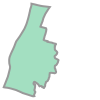

In [11]:
test_ward_polygon = df.iloc[0,:].geometry
test_ward_polygon

There is a truncate function. Let's try that:

In [12]:
# https://osmnx.readthedocs.io/en/stable/user-reference.html
test_ward_G = ox.truncate.truncate_graph_polygon(G, test_ward_polygon)

In [13]:
test_ward_G

Plot this:

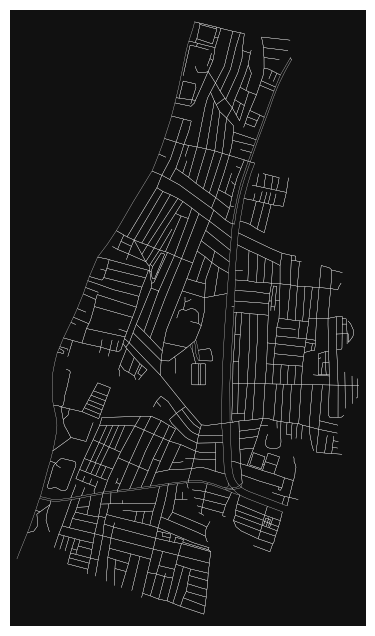

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [14]:
ox.plot_graph(test_ward_G, node_size=0, edge_color="w", edge_linewidth=0.2)

Convert to a Geopandas dataframe and read this into QGIS (for checking):

In [ ]:
test_stats = ox.basic_stats(test_ward_G)
test_stats

Compute the statistics:

In [15]:
# Reproject first:
test_ward_G_proj = ox.project_graph(test_ward_G)

In [16]:
test_stats = ox.basic_stats(test_ward_G_proj)
test_stats

{'n': 825,
 'm': 2178,
 'k_avg': 5.28,
 'edge_length_total': 141431.73477307576,
 'edge_length_avg': 64.93651734301,
 'streets_per_node_avg': 2.8327272727272725,
 'streets_per_node_counts': {0: 0, 1: 134, 2: 0, 3: 562, 4: 128, 5: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.16242424242424242,
  2: 0.0,
  3: 0.6812121212121212,
  4: 0.15515151515151515,
  5: 0.0012121212121212121},
 'intersection_count': 691,
 'street_length_total': 75687.55935546725,
 'street_segment_count': 1145,
 'street_length_avg': 66.10267192617228,
 'circuity_avg': 1.0425919217193154,
 'self_loop_proportion': 0.0017467248908296944}

In [ ]:
test_ward_G_edges = ox.truncate.truncate_graph_polygon(G, test_ward_polygon,truncate_by_edge=True)

In [ ]:
ox.plot_graph(test_ward_G_edges, node_size=0, edge_color="w", edge_linewidth=0.2)

In [ ]:
test_ward_G_edges2 = ox.truncate.truncate_graph_polygon(G, test_ward_polygon,truncate_by_edge=False)

In [ ]:
ox.plot_graph(test_ward_G_edges2, node_size=0, edge_color="w", edge_linewidth=0.2)

### Clipping to one ward: Through osmnx

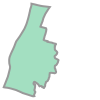

In [18]:
test_ward_polygon = df.iloc[0,:].geometry
test_ward_polygon

In [19]:
G_ward_2 = ox.graph_from_polygon(
        test_ward_polygon,
        simplify=True)

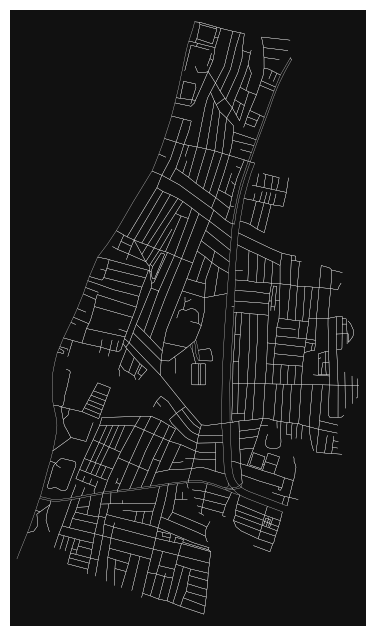

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [20]:
ox.plot_graph(G_ward_2, node_size=0, edge_color="w", edge_linewidth=0.2)

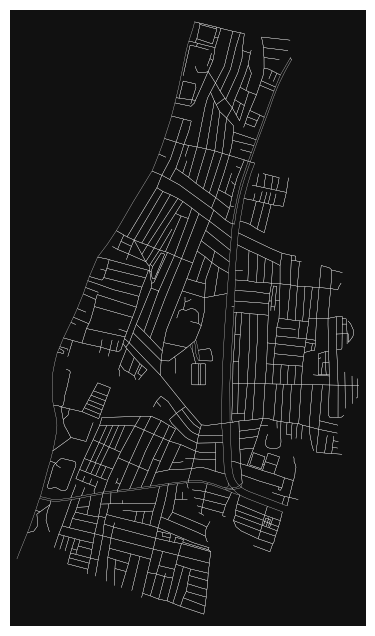

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [21]:
ox.plot_graph(test_ward_G, node_size=0, edge_color="w", edge_linewidth=0.2)

This looks the same!!

Test one ward that has multiple polygons (2 - Aerocity):

In [22]:
test_ward_polygon2 = df.iloc[1,:].geometry

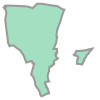

In [23]:
test_ward_polygon2

In [24]:
test_ward_G2 = ox.truncate.truncate_graph_polygon(G, test_ward_polygon2)

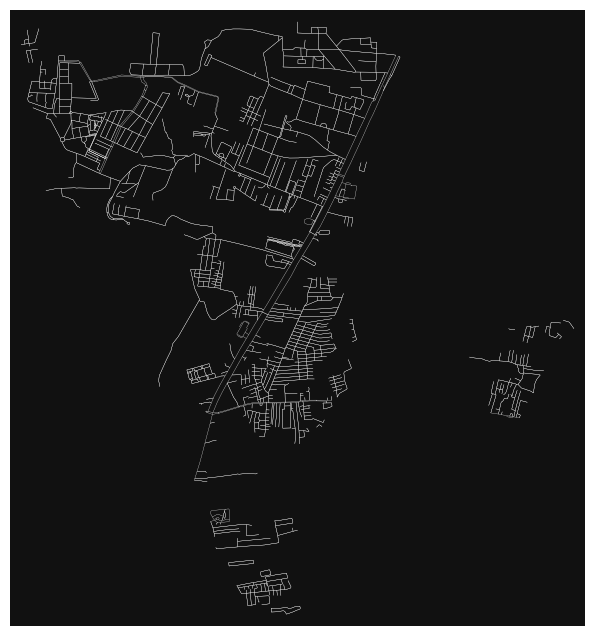

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [25]:
ox.plot_graph(test_ward_G2, node_size=0, edge_color="w", edge_linewidth=0.2)

In [26]:
test_ward_G_proj2 = ox.project_graph(test_ward_G2)

In [28]:
test_stats2 = ox.basic_stats(test_ward_G_proj2)
test_stats2

{'n': 1366,
 'm': 3163,
 'k_avg': 4.63103953147877,
 'edge_length_total': 232123.24533640812,
 'edge_length_avg': 73.38705195586725,
 'streets_per_node_avg': 2.5768667642752563,
 'streets_per_node_counts': {0: 0, 1: 367, 2: 0, 3: 843, 4: 156},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.2686676427525622,
  2: 0.0,
  3: 0.6171303074670571,
  4: 0.11420204978038068},
 'intersection_count': 999,
 'street_length_total': 124800.28092230415,
 'street_segment_count': 1699,
 'street_length_avg': 73.45513885950804,
 'circuity_avg': 1.1056305599119047,
 'self_loop_proportion': 0.005885815185403178}

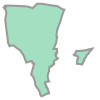

In [37]:
test_ward_polygon2

In [38]:
G_ward_2 = ox.graph_from_polygon(
        test_ward_polygon2,
        simplify=True)

It is strange that the multipolygon is not only taking the biggest part!

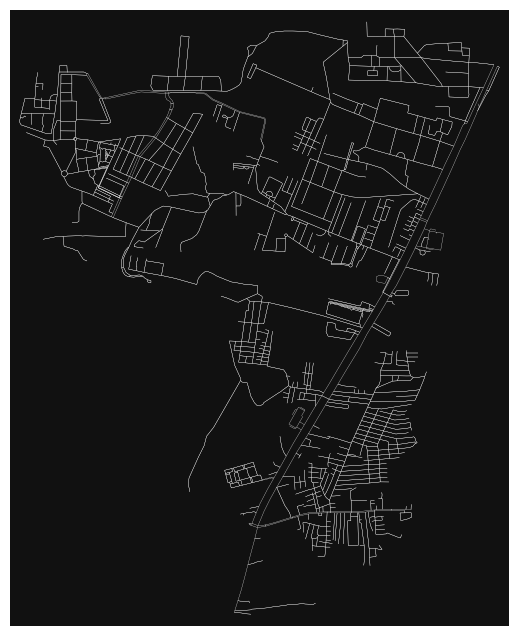

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [39]:
ox.plot_graph(G_ward_2, node_size=0, edge_color="w", edge_linewidth=0.2)

In [30]:
test_ward_G_proj2 = ox.project_graph(G_ward_2)

In [31]:
test_stats2 = ox.basic_stats(test_ward_G_proj2)
test_stats2

{'n': 1127,
 'm': 2719,
 'k_avg': 4.825199645075421,
 'edge_length_total': 199752.4865452527,
 'edge_length_avg': 73.46542351793038,
 'streets_per_node_avg': 2.6415261756876665,
 'streets_per_node_counts': {0: 0, 1: 270, 2: 0, 3: 721, 4: 136},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.23957409050576753,
  2: 0.0,
  3: 0.639751552795031,
  4: 0.12067435669920142},
 'intersection_count': 857,
 'street_length_total': 108029.34755606606,
 'street_segment_count': 1463,
 'street_length_avg': 73.8409757731142,
 'circuity_avg': 1.0909687647568087,
 'self_loop_proportion': 0.004101161995898838}